In [11]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [12]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation, SumAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset
import tqdm
import sys
import os
# Add the project root to the Python path
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import TUDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
from bcosgnn.evaluation import get_attribution_scores
import time

In [13]:
import importlib
import bcosgnn.evaluation
importlib.reload(bcosgnn.evaluation)
from bcosgnn.evaluation import get_attribution_scores

In [14]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [15]:
# Load Dataset (pre-saved .pt with node ground-truth masks)
dataset_path = project_root / "shaique_updates" / "codes" / "mutag_experiments" / "mutag_balanced_explainability.pt"
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

dataset_obj = torch.load(dataset_path, map_location="cpu", weights_only=False)

def _is_data_obj(obj):
    return hasattr(obj, "x") and hasattr(obj, "edge_index")

def _flatten_dict_dataset(dct):
    values = list(dct.values())
    # If values are Data objects
    if all(_is_data_obj(v) for v in values):
        return list(values)
    # If values are lists/tuples of Data objects
    if all(isinstance(v, (list, tuple)) for v in values):
        flat = []
        for v in values:
            flat.extend(list(v))
        return flat
    # If one common key holds the dataset
    for key in ("dataset", "data", "graphs", "items"):
        if key in dct:
            return list(dct[key]) if not isinstance(dct[key], list) else dct[key]
    return list(dct)  # fallback to keys (likely wrong, but explicit)

if isinstance(dataset_obj, dict):
    dataset = _flatten_dict_dataset(dataset_obj)
elif isinstance(dataset_obj, (list, tuple)):
    dataset = list(dataset_obj)
else:
    dataset = dataset_obj

# Normalize to a list for downstream splitting/statistics
if not isinstance(dataset, list):
    dataset = list(dataset)

print(f"Loaded dataset from: {dataset_path}")
print(f"Number of graphs: {len(dataset)}")

def _get_label(d):
    y = d.y
    if torch.is_tensor(y):
        return int(y.view(-1)[0].item())
    return int(y)

def _get_num_features(d):
    return int(d.x.shape[-1])

num_features = _get_num_features(dataset[0])
edge_dim = int(dataset[0].edge_attr.shape[-1]) if getattr(dataset[0], "edge_attr", None) is not None else 0
print(f"Number of features: {num_features}")
print(f"Edge attr dim: {edge_dim}")

# Statistics
class_counts = {0: 0, 1: 0}
total_nodes = 0
class_nodes = {0: 0, 1: 0}

for data in dataset:
    y = _get_label(data)
    class_counts[y] += 1
    total_nodes += data.num_nodes
    class_nodes[y] += data.num_nodes

print(f"\nClass Distribution:")
print(f"  Class 0 (Mutagenic):     {class_counts[0]} graphs")
print(f"  Class 1 (Non-mutagenic): {class_counts[1]} graphs")

print(f"\nNode Statistics:")
print(f"  Average nodes (Total):   {total_nodes / len(dataset):.2f}")
print(f"  Average nodes (Class 0): {class_nodes[0] / class_counts[0]:.2f}")
print(f"  Average nodes (Class 1): {class_nodes[1] / class_counts[1]:.2f}")

# Split Dataset
labels = [_get_label(d) for d in dataset]
train_dataset, test_dataset = train_test_split(
    dataset, test_size=0.2, random_state=42, stratify=labels
 )
print(f"\nTrain set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loaded dataset from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/mutag_experiments/mutag_balanced_explainability.pt
Number of graphs: 2030
Number of features: 14
Edge attr dim: 3

Class Distribution:
  Class 0 (Mutagenic):     1015 graphs
  Class 1 (Non-mutagenic): 1015 graphs

Node Statistics:
  Average nodes (Total):   29.29
  Average nodes (Class 0): 27.55
  Average nodes (Class 1): 31.02

Train set size: 1624
Test set size: 406


In [16]:
# -------------------------
# Cell 5: Model Classes
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_add_pool

# ==========================================
# 2. MODEL CLASSES
# ==========================================
class MaskableGINEConv(MessagePassing):
    def __init__(self, nn_mlp, train_eps=False):
        super().__init__(aggr='add') 
        self.nn = nn_mlp
        self.initial_eps = 0.0
        if train_eps:
            self.initial_eps = torch.nn.Parameter(torch.Tensor([0.0]))
            
    def forward(self, x, edge_index, edge_attr, edge_weight=None):
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr, edge_weight=edge_weight)
        x_r = x[1] if isinstance(x, tuple) else x
        out = out + (1 + self.initial_eps) * x_r
        return self.nn(out)

    def message(self, x_j, edge_attr, edge_weight):
        msg = F.relu(x_j + edge_attr)
        if edge_weight is not None:
            msg = msg * edge_weight.view(-1, 1)
        
        return msg



In [17]:
class GINE_Network(nn.Module):
    def __init__(self, in_channels, edge_dim, hidden_channels, out_channels):
        super().__init__()
        self.node_lin = nn.Linear(in_channels, hidden_channels)
        self.edge_lin = nn.Linear(edge_dim, hidden_channels)
        
        mlp1 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels), 
            nn.BatchNorm1d(hidden_channels), 
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = MaskableGINEConv(mlp1, train_eps=True)
        
        mlp2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels), 
            nn.BatchNorm1d(hidden_channels), 
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = MaskableGINEConv(mlp2, train_eps=True)
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr, edge_weight=None, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
            
        x = self.node_lin(x.float())
        edge_attr = self.edge_lin(edge_attr.float())
        
        x = self.conv1(x, edge_index, edge_attr, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr, edge_weight)
        x = F.relu(x)
        
        x = global_add_pool(x, batch)
        return self.lin(x)

class GSAT(nn.Module):
    def __init__(self, backbone, in_channels, edge_attr_dim, hidden_channels, temperature=1.0):
        super(GSAT, self).__init__()
        self.backbone = backbone
        self.temperature = temperature

        self.att_mlp = nn.Sequential(
            nn.Linear(in_channels * 2 + edge_attr_dim, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )
        
        for m in self.att_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def get_mask(self, x, edge_index, edge_attr, training=True):
        row, col = edge_index
        edge_rep = torch.cat([x[row], x[col], edge_attr], dim=-1)
        edge_logits = self.att_mlp(edge_rep).view(-1)

        if training:
            u = torch.rand_like(edge_logits)
            noise = torch.log(u + 1e-8) - torch.log(1 - u + 1e-8)
            stochastic_mask = torch.sigmoid((edge_logits + noise) / self.temperature)
        else:
            stochastic_mask = torch.sigmoid(edge_logits)
            
        return stochastic_mask, edge_logits

    def forward(self, data, training=True):
        x, edge_index, edge_attr, batch = data.x.float(), data.edge_index, data.edge_attr.float(), data.batch
        mask, mask_logits = self.get_mask(x, edge_index, edge_attr, training=training)
        pred_logits = self.backbone(x, edge_index, edge_attr, edge_weight=mask, batch=batch)
        return pred_logits, mask, mask_logits

In [18]:
# ==========================================
# 3. LOSS FUNCTION
# ==========================================
def gsat_loss(pred_logits, ground_truth_labels, mask_logits, r=0.7, pred_loss_coef=1.0, info_loss_coef=1.0):
    criterion = nn.CrossEntropyLoss()
    pred_loss = criterion(pred_logits, ground_truth_labels)
    
    mask_probs = torch.sigmoid(mask_logits)
    prior_target = torch.full_like(mask_probs, 1.0 - r)
    info_loss = F.binary_cross_entropy(mask_probs, prior_target, reduction='mean')
    
    loss = (pred_loss_coef * pred_loss) + (info_loss_coef * info_loss)
    return loss, pred_loss, info_loss

In [ ]:
EPOCH = 100
LR = 1e-3
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7
INFO_LOSS_COEF = 1.0

results = results = {"acc": [], "f1": [], "auc": [], "jaccard": []}

train_dataset = 


In [9]:
# Make sure to import f1_score at the top of your notebook if you haven't already:
from sklearn.metrics import f1_score, roc_auc_score
import time
import torch
import numpy as np
from torch_geometric.loader import DataLoader

# ==========================================
# 4. EXPERIMENT LOOP
# ==========================================
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7
INFO_LOSS_COEF = 1.0

# ADDED: "f1" to the results dictionary
results = {"acc": [], "f1": [], "auc": [], "jaccard": [], "avg_epoch_time": []}

print(f"\nStarting 5-Fold Run on: {DEVICE}")
print("-" * 80)

for run_id, seed in enumerate(SEEDS):
    print(f"Run {run_id+1}/{len(SEEDS)} (Seed: {seed})")
    
    set_seed(seed)
    dataset_shuffled = dataset.copy()
    random.shuffle(dataset_shuffled)    
    train_size = int(len(dataset_shuffled) * 0.8)
    train_dataset = dataset_shuffled[:train_size]
    test_dataset = dataset_shuffled[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    backbone = GINE_Network(
        in_channels=dataset.num_features,
        edge_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        out_channels=dataset.num_classes   
    )
    
    model = GSAT(
        backbone=backbone,
        in_channels=dataset.num_features,
        edge_attr_dim=dataset.num_edge_features,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    seed_epoch_times = []
    
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
        
        for data in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            logits, mask, mask_logits = model(data, training=True)
            loss, _, _ = gsat_loss(logits, data.y, mask_logits, r=R_PRIOR, pred_loss_coef=1.0, info_loss_coef=INFO_LOSS_COEF)
            loss.backward()
            optimizer.step()
            
        seed_epoch_times.append(time.time() - epoch_start)

    avg_time = np.mean(seed_epoch_times)
    results["avg_epoch_time"].append(avg_time)
            
    # Evaluation
    model.eval()
    correct_graphs, total_graphs = 0, 0
    run_jaccards, all_gt, all_pred = [], [], []
    
    # ADDED: Lists to store true labels and predictions for F1
    run_true_labels = []
    run_pred_labels = []
    
    has_explanations = False
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            
            # Accuracy and F1 Prep
            pred_classes = logits.argmax(dim=1)
            correct_graphs += (pred_classes == data.y).sum().item()
            total_graphs += data.num_graphs
            
            # ADDED: Store labels for F1 calculation
            run_true_labels.extend(data.y.cpu().numpy())
            run_pred_labels.extend(pred_classes.cpu().numpy())
            
            # Explanation Metrics (AUC/Jaccard)
            if hasattr(data, 'explanation_mask') and data.explanation_mask is not None:
                has_explanations = True
                row, col = data.edge_index
                node_mask = data.explanation_mask.bool()
                edge_gt = (node_mask[row] & node_mask[col]).cpu().numpy()
                all_gt.extend(edge_gt)
                all_pred.extend(mask.cpu().numpy())
                
                edge_batch = data.batch[row]
                pred_binary = (mask > 0.5).float()
                gt_binary = (node_mask[row] & node_mask[col]).float()
                
                intersection = pred_binary * gt_binary
                union = (pred_binary + gt_binary).clamp(max=1.0)
                
                graph_intersection = torch.zeros(data.num_graphs, device=DEVICE).scatter_add_(0, edge_batch, intersection)
                graph_union = torch.zeros(data.num_graphs, device=DEVICE).scatter_add_(0, edge_batch, union)
                
                run_jaccards.extend((graph_intersection / (graph_union + 1e-8)).cpu().tolist())

    final_acc = correct_graphs / total_graphs
    
    # ADDED: Calculate F1 Score using 'macro' average to handle imbalance
    final_f1 = f1_score(run_true_labels, run_pred_labels, average='macro')
    
    final_auc = roc_auc_score(all_gt, all_pred) if has_explanations and len(set(all_gt)) > 1 else np.nan
    final_jaccard = np.mean(run_jaccards) if has_explanations else np.nan
    
    # ADDED: Print F1 score
    print(f"  -> Avg Epoch Time: {avg_time:.4f}s | Acc: {final_acc:.4f} | F1: {final_f1:.4f}", end="")
    if has_explanations:
        print(f" | AUC: {final_auc:.4f} | Jaccard: {final_jaccard:.4f}")
    else:
        print(" | (No explanation ground truths in dataset)")
        
    results["acc"].append(final_acc)
    results["f1"].append(final_f1)   # ADDED: Save to results
    if has_explanations:
        results["auc"].append(final_auc)
        results["jaccard"].append(final_jaccard)

print("-" * 80)
print(f"Final Results over {len(SEEDS)} Seeds:")
print(f"Avg Time Per Epoch: {np.mean(results['avg_epoch_time']):.4f}s ± {np.std(results['avg_epoch_time']):.4f}")
print(f"Test Accuracy:      {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"Test F1 Score:      {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}") # ADDED: Final F1 summary

if len(results["auc"]) > 0:
    print(f"Explanation AUC:    {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}")
    print(f"Explanation Jaccard:{np.mean(results['jaccard']):.4f} ± {np.std(results['jaccard']):.4f}")


Starting 5-Fold Run on: cpu
--------------------------------------------------------------------------------
Run 1/5 (Seed: 0)


AttributeError: 'list' object has no attribute 'num_features'


Starting 5-Fold Run on: cpu
--------------------------------------------------------------------------------
Run 1/5 (Seed: 0)
  -> Avg Epoch Time: 0.2331s | Acc: 0.9015 | F1: 0.9015 | AUC: 0.6131 | Jaccard: 0.2047
Run 2/5 (Seed: 1)
  -> Avg Epoch Time: 0.2314s | Acc: 0.8547 | F1: 0.8544 | AUC: 0.6362 | Jaccard: 0.2005
Run 3/5 (Seed: 2)
  -> Avg Epoch Time: 0.2304s | Acc: 0.8768 | F1: 0.8768 | AUC: 0.6382 | Jaccard: 0.1744
Run 4/5 (Seed: 3)
  -> Avg Epoch Time: 0.2302s | Acc: 0.8842 | F1: 0.8839 | AUC: 0.6178 | Jaccard: 0.2059
Run 5/5 (Seed: 4)
  -> Avg Epoch Time: 0.2286s | Acc: 0.8768 | F1: 0.8758 | AUC: 0.6198 | Jaccard: 0.2059
--------------------------------------------------------------------------------
Final Results over 5 Seeds:
Avg Time Per Epoch: 0.2307s ± 0.0015
Test Accuracy:      0.8788 ± 0.0151
Test F1 Score:      0.8785 ± 0.0152
Explanation AUC:    0.6250 ± 0.0102
Explanation Jaccard:0.1983 ± 0.0121


[17:48:05] Explicit valence for atom # 10 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 8 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 15 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 19 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 10 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 8 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 15 N, 4, is greater than permitted
[17:48:05] Explicit valence for atom # 19 N, 4, is greater than permitted


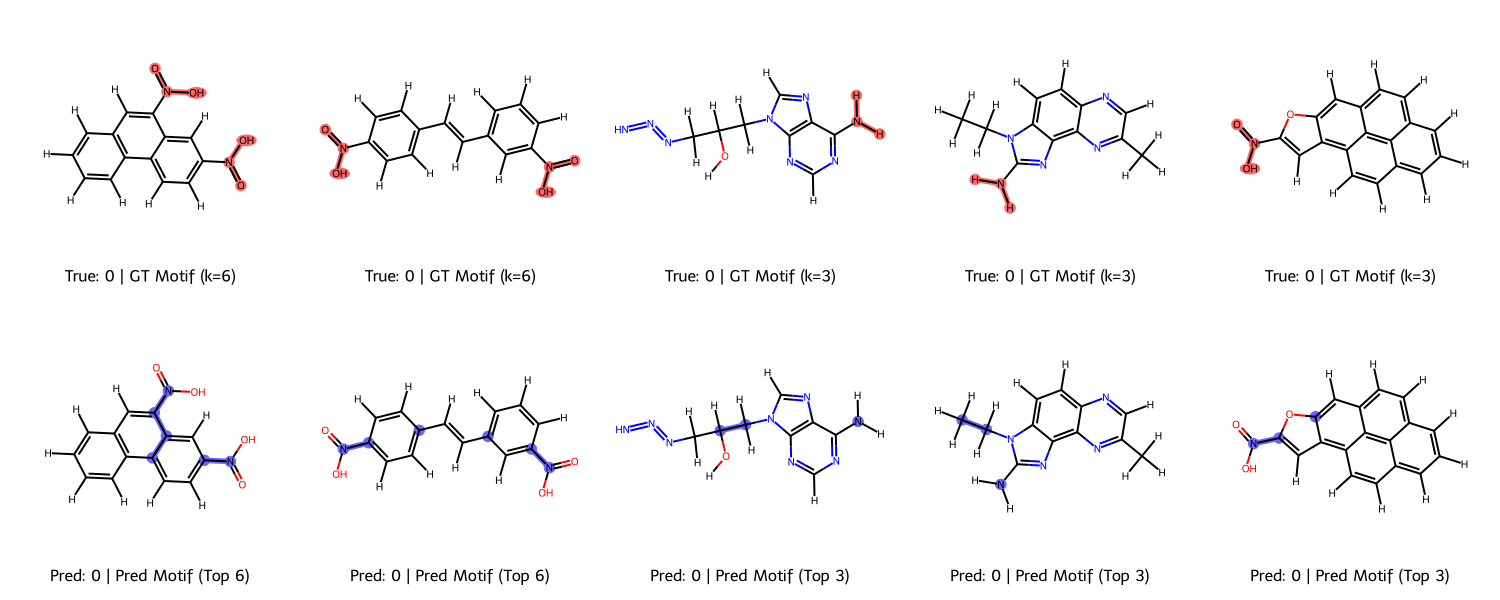

In [19]:
import time
import random
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def _get_node_mask(data):
    for name in ("explanation_mask", "node_mask", "node_gt_mask", "gt_node_mask"):
        if hasattr(data, name) and getattr(data, name) is not None:
            mask = getattr(data, name)
            if torch.is_tensor(mask):
                mask = mask.detach().cpu().numpy()
            return mask.astype(int)
    return None

def dynamic_jaccard_at_k(preds, targets):
    jaccards = []
    for pred, target in zip(preds, targets):
        k = int(target.sum())
        if k == 0:
            jaccards.append(float('nan'))
            continue
        topk_idx = pred.argsort()[-k:][::-1]
        pred_set = set(topk_idx)
        true_set = set(np.where(target)[0])
        intersection = len(pred_set & true_set)
        union = len(pred_set | true_set)
        jaccards.append(intersection / union if union > 0 else 0.0)
    return jaccards

# RDKit Map
ATOM_MAP = {
    0: 'C', 1: 'O', 2: 'Cl', 3: 'H', 4: 'N', 5: 'F', 
    6: 'Br', 7: 'S', 8: 'P', 9: 'I', 10: 'Na', 11: 'K', 12: 'Li', 13: 'Ca'
}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_types = data.x.argmax(dim=1).cpu().numpy() if data.x.dim() > 1 else data.x.cpu().numpy()
    
    for nt in node_types:
        symbol = ATOM_MAP.get(int(nt), 'C')
        mol.AddAtom(Chem.Atom(symbol))
        
    added_edges = set()
    edges = data.edge_index.t().cpu().numpy()
    
    if hasattr(data, 'edge_attr') and data.edge_attr is not None:
        edge_attrs = data.edge_attr.argmax(dim=1).cpu().numpy() if data.edge_attr.dim() > 1 else data.edge_attr.cpu().numpy()
    else:
        edge_attrs = [0] * len(edges)
        
    for e_idx, (u, v) in enumerate(edges):
        if u < v and (u, v) not in added_edges:
            bond_type = Chem.rdchem.BondType.SINGLE
            if edge_attrs[e_idx] == 1: bond_type = Chem.rdchem.BondType.DOUBLE
            elif edge_attrs[e_idx] == 2: bond_type = Chem.rdchem.BondType.AROMATIC
            elif edge_attrs[e_idx] == 3: bond_type = Chem.rdchem.BondType.TRIPLE
            mol.AddBond(int(u), int(v), bond_type)
            added_edges.add((u, v))
            
    Chem.SanitizeMol(mol, catchErrors=True)
    rdDepictor.Compute2DCoords(mol)
    return mol.GetMol()


# ==========================================
# 2. EXPERIMENT SETUP
# ==========================================
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100
LR = 1e-3
HIDDEN_DIM = 64
R_PRIOR = 0.7
INFO_LOSS_COEF = 1.0

# Extract dimensions from the first graph to avoid the list attribute error
num_features = dataset[0].x.shape[-1]
num_edge_features = dataset[0].edge_attr.shape[-1] if dataset[0].edge_attr is not None else 0
num_classes = 2 # MUTAG is binary

results = {"acc": [], "f1": [], "auc": [], "jaccard": [], "avg_epoch_time": []}

print(f"\nStarting 5-Fold Run on: {DEVICE}")
print("-" * 80)

# ==========================================
# 3. TRAINING & EVALUATION LOOP
# ==========================================
for run_id, seed in enumerate(SEEDS):
    print(f"Run {run_id+1}/{len(SEEDS)} (Seed: {seed})")
    
    set_seed(seed)
    dataset_shuffled = dataset.copy()
    random.shuffle(dataset_shuffled)    
    train_size = int(len(dataset_shuffled) * 0.8)
    train_dataset = dataset_shuffled[:train_size]
    test_dataset = dataset_shuffled[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    backbone = GINE_Network(
        in_channels=num_features,
        edge_dim=num_edge_features,
        hidden_channels=HIDDEN_DIM,
        out_channels=num_classes   
    )
    
    model = GSAT(
        backbone=backbone,
        in_channels=num_features,
        edge_attr_dim=num_edge_features,
        hidden_channels=HIDDEN_DIM,
        temperature=1.0
    ).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    seed_epoch_times = []
    
    # Train
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        model.temperature = 1.0 - (epoch / EPOCHS) * (1.0 - 0.1)
        
        for data in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            logits, mask, mask_logits = model(data, training=True)
            loss, _, _ = gsat_loss(logits, data.y, mask_logits, r=R_PRIOR, pred_loss_coef=1.0, info_loss_coef=INFO_LOSS_COEF)
            loss.backward()
            optimizer.step()
            
        seed_epoch_times.append(time.time() - epoch_start)

    avg_time = np.mean(seed_epoch_times)
    results["avg_epoch_time"].append(avg_time)
            
    # Evaluate
    model.eval()
    run_true_labels, run_pred_labels = [], []
    run_node_preds, run_node_targets, run_aurocs = [], [], []
    
    has_explanations = False
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(DEVICE)
            logits, mask, _ = model(data, training=False)
            
            # Prediction metrics
            pred_classes = logits.argmax(dim=1)
            run_true_labels.extend(data.y.cpu().numpy())
            run_pred_labels.extend(pred_classes.cpu().numpy())
            
        # Explainability Metrics (Evaluated per graph to match dynamic K)
        for data in test_dataset:
            gt_mask = _get_node_mask(data)
            if gt_mask is None:
                continue
                
            has_explanations = True
            data = data.clone().to(DEVICE)
            data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
            
            logits, edge_mask, _ = model(data, training=False)
            edge_mask = edge_mask.view(-1)
            
            # GSAT outputs edges. Aggregate to node scores
            node_scores = torch.zeros(data.num_nodes, device=DEVICE)
            node_scores.scatter_add_(0, data.edge_index[0], edge_mask)
            node_scores = node_scores.cpu().numpy()
            
            run_node_preds.append(node_scores)
            run_node_targets.append(gt_mask)
            
            if gt_mask.min() != gt_mask.max():
                run_aurocs.append(roc_auc_score(gt_mask, node_scores))

    # Compile Seed Results
    final_acc = accuracy_score(run_true_labels, run_pred_labels)
    final_f1 = f1_score(run_true_labels, run_pred_labels, average='macro')
    
    final_auc = np.mean(run_aurocs) if run_aurocs else np.nan
    if has_explanations:
        jaccards = dynamic_jaccard_at_k(run_node_preds, run_node_targets)
        valid_jaccards = [j for j in jaccards if not np.isnan(j)]
        final_jaccard = np.mean(valid_jaccards) if valid_jaccards else np.nan
    else:
        final_jaccard = np.nan
    
    print(f"  -> Avg Epoch Time: {avg_time:.4f}s | Acc: {final_acc:.4f} | F1: {final_f1:.4f}", end="")
    if has_explanations:
        print(f" | AUC: {final_auc:.4f} | Jaccard: {final_jaccard:.4f}")
    else:
        print(" | (No explanation ground truths in dataset)")
        
    results["acc"].append(final_acc)
    results["f1"].append(final_f1)
    if has_explanations:
        results["auc"].append(final_auc)
        results["jaccard"].append(final_jaccard)

print("-" * 80)
print(f"Final Results over {len(SEEDS)} Seeds:")
print(f"Avg Time Per Epoch: {np.mean(results['avg_epoch_time']):.4f}s ± {np.std(results['avg_epoch_time']):.4f}")
print(f"Test Accuracy:      {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"Test F1 Score:      {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")

if len(results["auc"]) > 0:
    print(f"Explanation AUC:    {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
    print(f"Explanation Jaccard:{np.nanmean(results['jaccard']):.4f} ± {np.nanstd(results['jaccard']):.4f}")

# ==========================================
# 4. RDKIT VISUALIZATION
# ==========================================
sample_graphs = []
for d in test_dataset: # Sourced from the last seed's split
    if _get_node_mask(d) is not None and d.y.item() == 0:
        sample_graphs.append(d)
    if len(sample_graphs) == 5:
        break

if sample_graphs:
    mols = []
    highlight_atoms = []
    highlight_colors = []
    legends = []

    processed_data = []
    model.eval()
    for data in sample_graphs:
        data = data.clone().to(DEVICE)
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
        
        with torch.no_grad():
            logits, edge_mask, _ = model(data, training=False)
            pred_label = logits.argmax(dim=1).item()
            
        edge_mask = edge_mask.view(-1)
        node_scores = torch.zeros(data.num_nodes, device=DEVICE).scatter_add_(0, data.edge_index[0], edge_mask).cpu().numpy()
        processed_data.append((data, node_scores, pred_label))

    # Top Row: Ground Truth Masks
    for data, node_scores, pred_label in processed_data:
        mol = pyg_to_rdkit(data)
        mols.append(mol)
        
        gt_mask = _get_node_mask(data)
        gt_indices = np.where(gt_mask)[0].tolist()
        
        highlight_atoms.append(gt_indices)
        highlight_colors.append({idx: (1.0, 0.4, 0.4) for idx in gt_indices}) # Red
        legends.append(f"True: {data.y.item()} | GT Motif (k={len(gt_indices)})")

    # Bottom Row: Predicted Motifs
    for data, node_scores, pred_label in processed_data:
        mol = pyg_to_rdkit(data)
        mols.append(mol)
        
        gt_mask = _get_node_mask(data)
        gt_k = int(gt_mask.sum())
        
        top_idx = node_scores.argsort()[-gt_k:][::-1].tolist() if gt_k > 0 else []
        
        highlight_atoms.append(top_idx)
        highlight_colors.append({idx: (0.4, 0.4, 1.0) for idx in top_idx}) # Blue
        legends.append(f"Pred: {pred_label} | Pred Motif (Top {gt_k})")

    img = Draw.MolsToGridImage(
        mols, molsPerRow=5, subImgSize=(300, 300), legends=legends,
        highlightAtomLists=highlight_atoms, highlightAtomColors=highlight_colors, useSVG=False
    )
    display(img)
else:
    print("\nVisualization Skipped: No ground-truth masks found to display.")